In [1]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.io import read_anndata

adata = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Consortium2022.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

dask: False, backed: False
Read slot "obs", store as "obs"...


/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


In [2]:
adata.obs["tissue"].unique()

['lymph node', 'thymus', 'liver', 'heart', 'lung', ..., 'posterior segment of eyeball', 'buccal mucosa', 'cornea', 'jejunum', 'eyelid']
Length: 75
Categories (75, object): ['endocrine pancreas', 'exocrine pancreas', 'lymph node', 'large intestine', ..., 'posterior part of tongue', 'ocular surface region', 'bladder organ', 'chorioretinal region']

In [3]:
adata

AnnData object with n_obs × n_vars = 1136218 × 60606
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'sample_number', 'suspension_type', 'tissue_type', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_j

In [4]:
adata.obs["cell_type"].nunique()

180

In [5]:
adata.obs["donor_id"].nunique()

24

In [6]:
adata.obs["assay"].nunique()

4

In [12]:
adata.obs["sample_id"].nunique()

658

In [8]:
adata.obs[["assay", "donor_id"]].drop_duplicates().value_counts("assay")

assay
10x 3' v3     22
Smart-seq2    17
10x 5' v2      5
Smart-seq3     2
Name: count, dtype: int64

In [9]:
adata.obs[["assay", "donor_id"]].drop_duplicates().value_counts("donor_id")

donor_id
TSP2     3
TSP30    3
TSP28    3
TSP14    3
TSP5     2
TSP1     2
TSP3     2
TSP4     2
TSP8     2
TSP7     2
TSP6     2
TSP10    2
TSP15    2
TSP20    2
TSP12    2
TSP11    2
TSP25    2
TSP21    2
TSP9     1
TSP13    1
TSP17    1
TSP19    1
TSP27    1
TSP26    1
Name: count, dtype: int64

In [2]:
batch_size = adata.obs["donor_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 47342.42
Standard deviation: 64028.12
Minimum batch size: 461
Maximum batch size: 213530
Coefficient of variance: 1.35


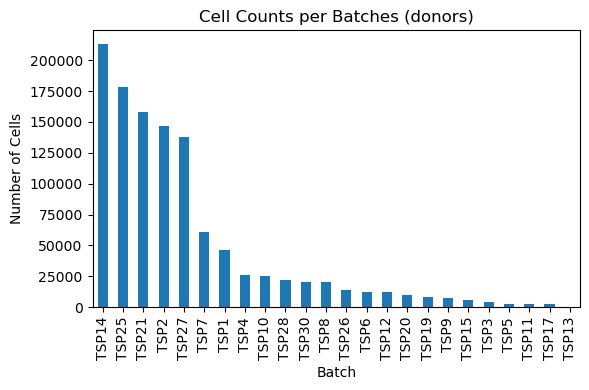

In [11]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (donors)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [3]:
def gini_py(values):
    """
    Compute the Gini coefficient of a list of non-negative numbers.
    Pure Python implementation (no NumPy).
    """
    values = list(values)

    if any(v < 0 for v in values):
        raise ValueError("All values must be non-negative.")

    if all(v == 0 for v in values):
        return 0.0

    # Sort values
    values.sort()
    n = len(values)
    total = sum(values)

    cumulative = 0
    weighted_sum = 0
    for i, v in enumerate(values, start=1):
        weighted_sum += (2 * i - n - 1) * v

    return weighted_sum / (n * total)

print(gini_py(batch_size))

0.6420385436597554
